<a href="https://colab.research.google.com/github/DrDourado/ME_615_Spring_2026/blob/main/ME_615_Instance_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook introduces a fundamental computer vision tasks commonly used in modern engineering inspection and monitoring systems:

**Image Segmentation** – identifying the precise pixels belonging to an object.

Object detection provides bounding boxes, but many engineering problems require pixel-level localization:
- crack detection
- corrosion mapping
- defect area estimation

This motivates image segmentation.

Image Segmentation: performs **pixel‑level classification**, i.e., each pixel in the image is assigned a label.

Types include:
- **Semantic segmentation** : Classifies pixels into object categories.
- **Instance segmentation** : Separates different objects belonging to the same class.

The notebook introduces **U-Net**, one of the most influential segmentation architectures.

Structure:
- *Encoder*: Extracts hierarchical image features.
- *Decoder*: Restores spatial resolution.
- *Skip connections*: Transfer spatial information from encoder to decoder.

This preserves fine structural detail critical for engineering inspection.

Diagrammatically:


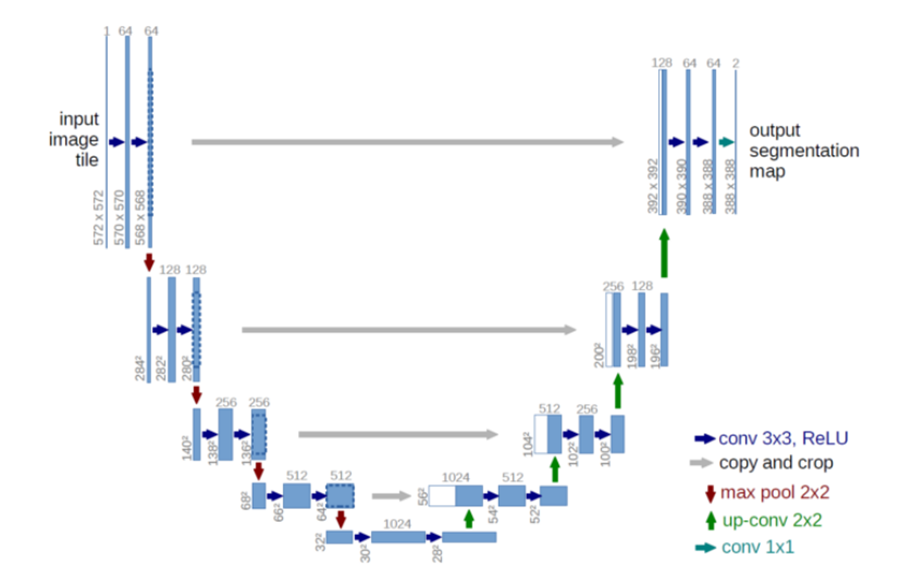


**Segmentation Dataset**:
The notebook uses the [Oxford-IIIT Pet dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/), which contains:

- RGB images
- segmentation masks

While not mechanical data, it is:
- lightweight
- well-annotated
- widely used.

By the end you should be able to easily transfer the pipeline to industrial inspection datasets.

**Transfer Learning for Segmentation** - The encoder portion of U-Net is replaced with a pretrained MobileNetV2.

Benefits:
- faster training
- improved feature extraction
- lower data requirements.

The decoder is trained to map features back into segmentation masks.

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

Helper Functions

In [2]:
def normalize(input_image, input_mask):
    input_image = tf.cast(input_image, tf.float32) / 255.0
    input_mask -= 1 # 1, 2, 3 -> 0, 1, 2
    return input_image, input_mask

def load_image_train(datapoint):
    input_image = tf.image.resize(datapoint['image'], (IMG_HEIGHT, IMG_WIDTH))
    input_mask = tf.image.resize(datapoint['segmentation_mask'], (IMG_HEIGHT, IMG_WIDTH))

    if tf.random.uniform(()) > 0.5:
        input_image = tf.image.flip_left_right(input_image)
        input_mask = tf.image.flip_left_right(input_mask)

    input_image, input_mask = normalize(input_image, input_mask)
    return input_image, input_mask

def load_image_test(datapoint):
    input_image = tf.image.resize(datapoint['image'], (IMG_HEIGHT, IMG_WIDTH))
    input_mask = tf.image.resize(datapoint['segmentation_mask'], (IMG_HEIGHT, IMG_WIDTH))
    input_image, input_mask = normalize(input_image, input_mask)
    return input_image, input_mask

def display(display_list):
    plt.figure(figsize=(15, 15))
    title = ['Input Image', 'True Mask', 'Predicted Mask']
    for i in range(len(display_list)):
        plt.subplot(1, len(display_list), i+1)
        plt.title(title[i])
        plt.imshow(tf.keras.utils.array_to_img(display_list[i]))
        plt.axis('off')
    plt.show()

In [3]:
# Define image dimensions
IMG_WIDTH = 128
IMG_HEIGHT = 128
NUM_CLASSES = 3  # For the Oxford-IIIT Pet dataset (background, animal, border)

# Load the dataset (without as_supervised to get the segmentation masks)
dataset, info = tfds.load('oxford_iiit_pet:4.0.0', with_info=True)

In [4]:
TRAIN_LENGTH = info.splits['train'].num_examples
BATCH_SIZE = 64
BUFFER_SIZE = 1000
STEPS_PER_EPOCH = TRAIN_LENGTH // BATCH_SIZE

train_batches = dataset['train'].map(load_image_train, num_parallel_calls=tf.data.AUTOTUNE)
test_batches = dataset['test'].map(load_image_test, num_parallel_calls=tf.data.AUTOTUNE)

train_batches = train_batches.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()
train_batches = train_batches.prefetch(buffer_size=tf.data.AUTOTUNE)
test_batches = test_batches.batch(BATCH_SIZE)

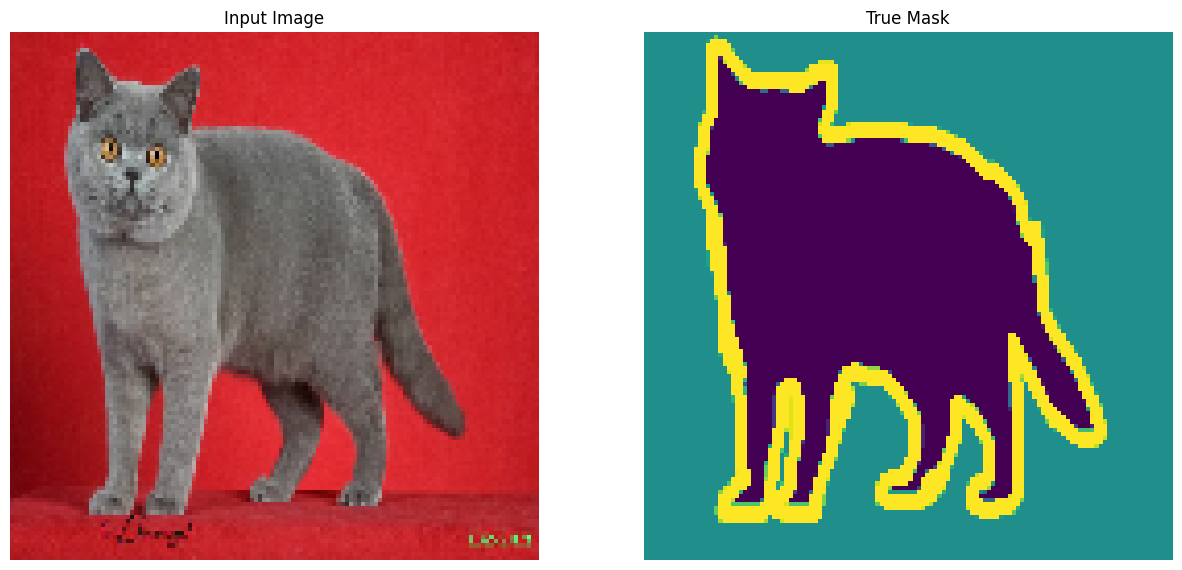

In [5]:
for image, mask in train_batches.take(1):
    sample_image, sample_mask = image[0], mask[0]
    display([sample_image, sample_mask])

### UNet Model Architecture

We will implement a UNet-like architecture. For the encoder path, we'll use a pre-trained MobileNetV2 model to leverage transfer learning, which can significantly improve performance and reduce training time. The decoder path will consist of upsampling layers that progressively restore the spatial resolution, concatenating with skip connections from the encoder to retain fine-grained details. The final layer will output a segmentation mask with `NUM_CLASSES` channels.

In [6]:
base_model = tf.keras.applications.MobileNetV2(input_shape=[128, 128, 3], include_top=False)

# Use the activations of these layers
layer_names = [
    'block_1_expand_relu',   # 64x64
    'block_3_expand_relu',   # 32x32
    'block_6_expand_relu',   # 16x16
    'block_13_expand_relu',  # 8x8
    'block_16_project',      # 4x4
]
base_model_outputs = [base_model.get_layer(name).output for name in layer_names]

# Create the feature extraction model
down_stack = tf.keras.Model(inputs=base_model.input, outputs=base_model_outputs)
down_stack.trainable = False

def upsample(filters, size, apply_dropout=False):
    initializer = tf.random_normal_initializer(0., 0.02)
    result = tf.keras.Sequential()
    result.add(
      tf.keras.layers.Conv2DTranspose(filters, size, strides=2,
                                      padding='same',
                                      kernel_initializer=initializer,
                                      use_bias=False))
    result.add(tf.keras.layers.BatchNormalization())
    if apply_dropout:
        result.add(tf.keras.layers.Dropout(0.5))
    result.add(tf.keras.layers.ReLU())
    return result

up_stack = [
    upsample(512, 3),  # 4x4 -> 8x8
    upsample(256, 3),  # 8x8 -> 16x16
    upsample(128, 3),  # 16x16 -> 32x32
    upsample(64, 3),   # 32x32 -> 64x64
]

def unet_model(output_channels:int):
    inputs = tf.keras.layers.Input(shape=[128, 128, 3])
    x = inputs

    # Downsampling through the model
    skips = down_stack(x)
    x = skips[-1]
    skips = reversed(skips[:-1])

    # Upsampling and establishing the skip connections
    for up, skip in zip(up_stack, skips):
        x = up(x)
        concat = tf.keras.layers.Concatenate()([x, skip])

    # This is the last layer of the model
    last = tf.keras.layers.Conv2DTranspose(
        filters=output_channels, kernel_size=3, strides=2,
        padding='same')  #64x64 -> 128x128

    x = last(concat)

    return tf.keras.Model(inputs=inputs, outputs=x)

model = unet_model(NUM_CLASSES)

In [7]:
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ [(None, 64, 64,   │  1,841,984 │ input_layer_1[0]… │
│ (Functional)        │ 96), (None, 32,   │            │                   │
│                     │ 32, 144), (None,  │            │                   │
│                     │ 16, 16, 192),     │            │                   │
│                     │ (None, 8, 8,      │            │                   │
│                     │ 576), (None, 4,   │            │                   │
│                     │ 4, 320)]          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 8, 8, 512) │  1,476,608 │ functional[0][4]  │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 16, 16,    │  1,180,672 │ sequential[0][0]  │
│ (Sequential)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 32, 32,    │    295,424 │ sequential_1[0][… │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_3        │ (None, 64, 64,    │     73,984 │ sequential_2[0][… │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 64, 64,    │          0 │ sequential_3[0][… │
│ (Concatenate)       │ 160)              │            │ functional[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 128, 128,  │      4,323 │ concatenate_3[0]… │
│ (Conv2DTranspose)   │ 3)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,872,995 (18.59 MB)

 Trainable params: 3,029,091 (11.56 MB)

 Non-trainable params: 1,843,904 (7.03 MB)

In [8]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

Training Loop with updated model performance at each epoch

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


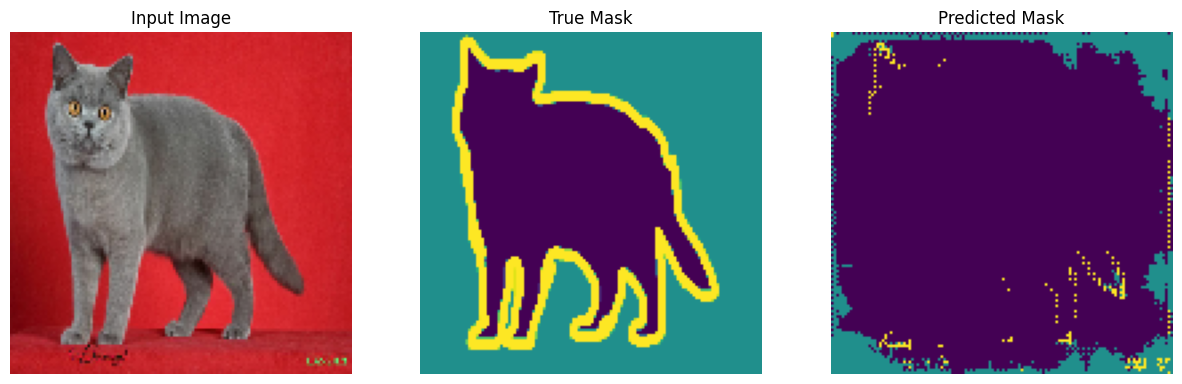


Sample Prediction after epoch 1

57/57 ━━━━━━━━━━━━━━━━━━━━ 323s 5s/step - accuracy: 0.6976 - loss: 0.7334 - val_accuracy: 0.3929 - val_loss: 1.6682
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


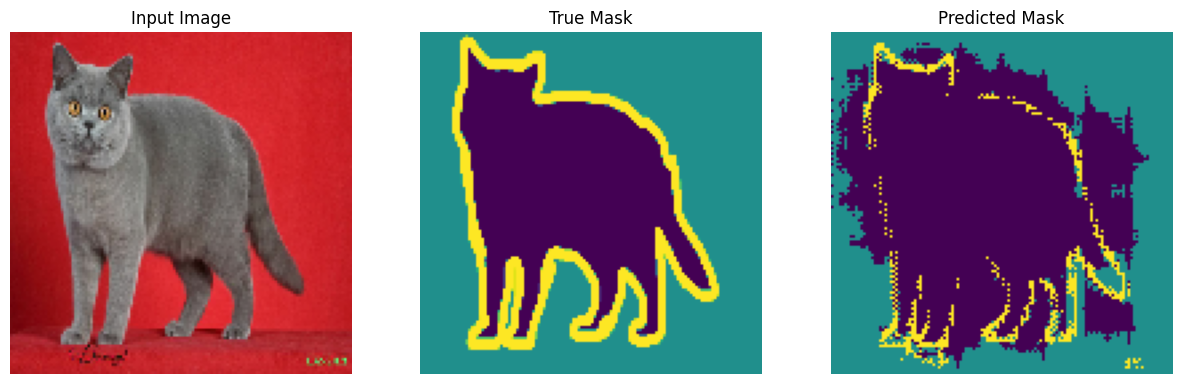


Sample Prediction after epoch 2

57/57 ━━━━━━━━━━━━━━━━━━━━ 279s 5s/step - accuracy: 0.7765 - loss: 0.5360 - val_accuracy: 0.5573 - val_loss: 1.1236
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


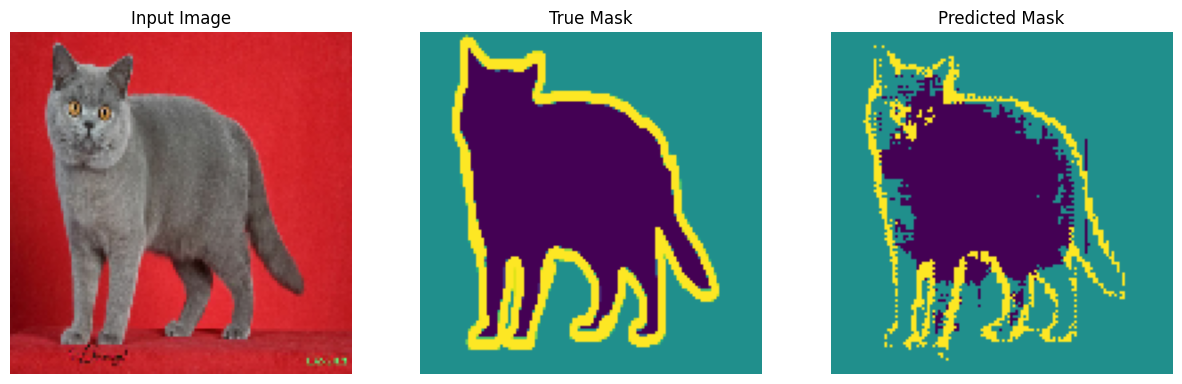


Sample Prediction after epoch 3

57/57 ━━━━━━━━━━━━━━━━━━━━ 294s 5s/step - accuracy: 0.7900 - loss: 0.5006 - val_accuracy: 0.7724 - val_loss: 0.5696
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


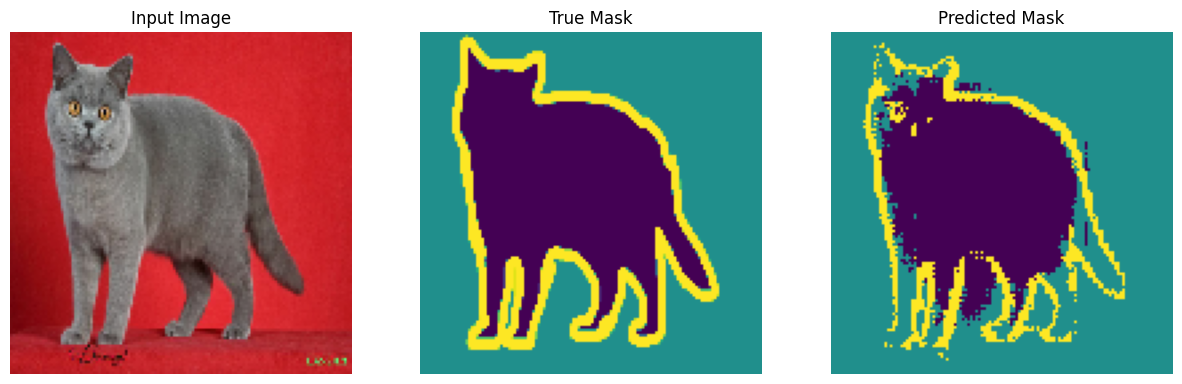


Sample Prediction after epoch 4

57/57 ━━━━━━━━━━━━━━━━━━━━ 284s 5s/step - accuracy: 0.7984 - loss: 0.4797 - val_accuracy: 0.7874 - val_loss: 0.5202
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step


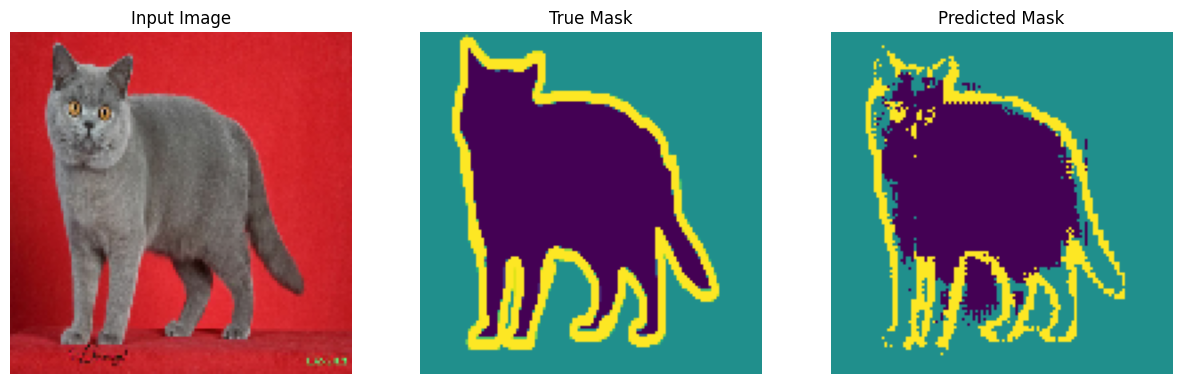


Sample Prediction after epoch 5

57/57 ━━━━━━━━━━━━━━━━━━━━ 322s 6s/step - accuracy: 0.8067 - loss: 0.4600 - val_accuracy: 0.7955 - val_loss: 0.5043


In [9]:
def create_mask(pred_mask):
    pred_mask = tf.argmax(pred_mask, axis=-1)
    pred_mask = pred_mask[..., tf.newaxis]
    return pred_mask[0]

def show_predictions(dataset=None, num=1):
    if dataset:
        for image, mask in dataset.take(num):
            pred_mask = model.predict(image)
            display([image[0], mask[0], create_mask(pred_mask)])
    else:
        display([sample_image, sample_mask, create_mask(model.predict(sample_image[tf.newaxis, ...]))])

class DisplayCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        show_predictions()
        print ('\nSample Prediction after epoch {}\n'.format(epoch+1))

EPOCHS = 5
VAL_SUBSPLITS = 5
VALIDATION_STEPS = info.splits['test'].num_examples // BATCH_SIZE // VAL_SUBSPLITS

model_history = model.fit(train_batches,
                          epochs=EPOCHS,
                          steps_per_epoch=STEPS_PER_EPOCH,
                          validation_steps=VALIDATION_STEPS,
                          validation_data=test_batches,
                          callbacks=[DisplayCallback()])

Testing Model Performance

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 923ms/step


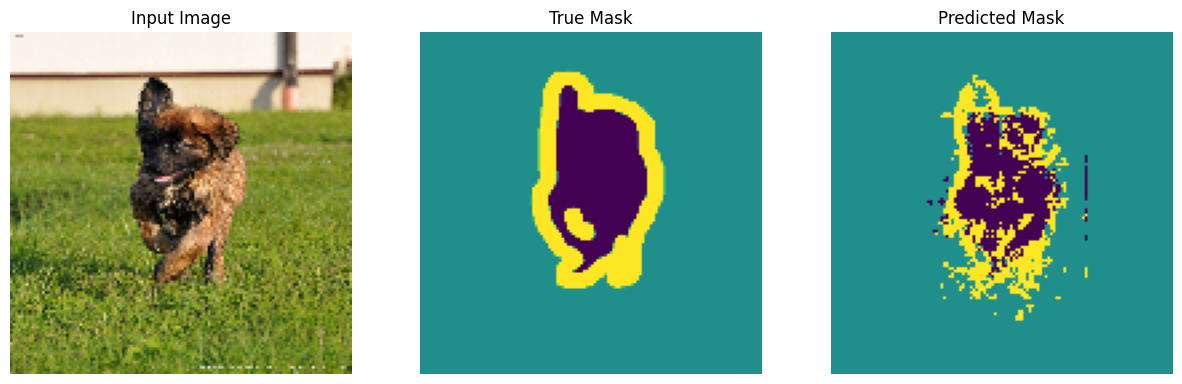

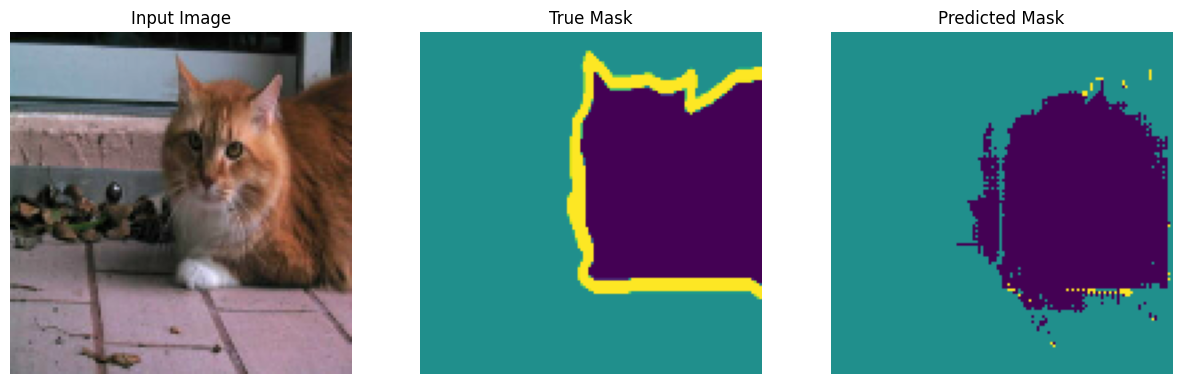

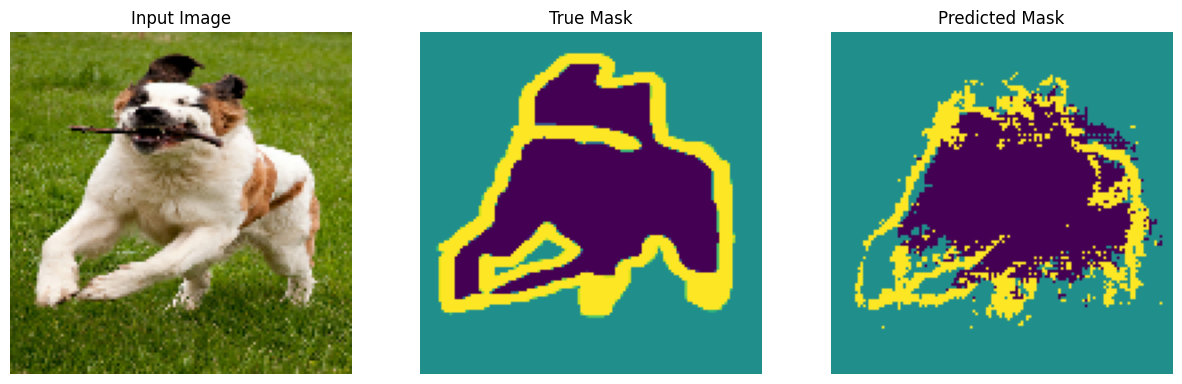

In [10]:
for image, mask in test_batches.take(1):
    sample_image, sample_mask = image, mask
    prediction_mask = model.predict(sample_image)

    # Display first few images from the batch
    for i in range(min(3, sample_image.shape[0])):
        display([sample_image[i], sample_mask[i], create_mask(prediction_mask[i][tf.newaxis, ...])])